In [192]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [193]:
df = pd.read_csv('dataset_2020_clean.csv')

# EDA Tahap 1

C:\Users\frans\AppData\Local\Temp\ipykernel_9080\2947440202.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




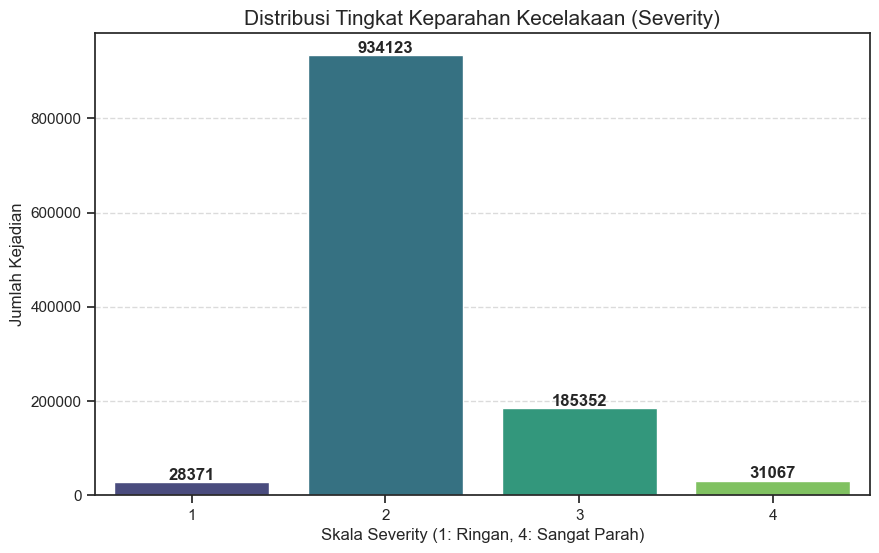

In [194]:
# Membuat bar chart untuk kolom Severity
severity_counts = df['Severity'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=severity_counts.index, y=severity_counts.values, palette='viridis')

plt.title('Distribusi Tingkat Keparahan Kecelakaan (Severity)', fontsize=15)
plt.xlabel('Skala Severity (1: Ringan, 4: Sangat Parah)', fontsize=12)
plt.ylabel('Jumlah Kejadian', fontsize=12)

for i, v in enumerate(severity_counts.values):
    plt.text(i, v + 5000, str(v), ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [195]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Tahun
0,A-1189513,Source2,2,2020-12-28 05:55:31,2021-01-18 05:00:00,39.376530,-74.478561,NaN,NaN,0.46,...,False,False,False,False,False,Night,Night,Night,Day,2020
1,A-1207989,Source2,3,2020-12-31 22:57:02,2021-01-01 00:29:02,41.932789,-88.038078,NaN,NaN,0.00,...,False,False,False,False,False,Night,Night,Night,Night,2020
2,A-1207990,Source2,3,2020-12-31 22:03:27,2021-01-01 01:43:05,41.623920,-87.680061,NaN,NaN,0.00,...,False,False,False,False,False,Night,Night,Night,Night,2020
3,A-1207991,Source2,3,2020-12-31 22:58:36,2021-01-01 01:02:45,41.794476,-87.631599,NaN,NaN,0.00,...,False,False,False,True,False,Night,Night,Night,Night,2020
4,A-1208128,Source2,2,2020-12-31 23:32:07,2021-01-01 00:51:14,39.771069,-104.847038,NaN,NaN,0.00,...,False,False,False,True,False,Night,Night,Night,Night,2020


In [196]:
df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Tahun
count,1.178913e+06,1.178913e+06,1.178913e+06,708669.000000,708669.000000,1.178913e+06,1.147949e+06,1.138750e+06,1.145679e+06,1.152998e+06,1.148557e+06,1.143152e+06,1.116511e+06,1178913.0
mean,2.185862e+00,3.623964e+01,-9.548162e+01,36.396725,-97.404569,4.492280e-01,5.981137e+01,5.862050e+01,6.608177e+01,2.935166e+01,9.017523e+00,7.136620e+00,6.017451e-03,2020.0
std,5.021481e-01,5.021891e+00,1.763442e+01,5.180773,18.517515,1.739455e+00,1.770719e+01,1.959923e+01,2.318382e+01,1.075922e+00,2.646711e+00,5.626493e+00,5.267433e-02,0.0
min,1.000000e+00,2.456309e+01,-1.244975e+02,24.574326,-124.497470,0.000000e+00,-8.900000e+01,-8.900000e+01,2.000000e+00,1.937000e+01,0.000000e+00,0.000000e+00,0.000000e+00,2020.0
25%,2.000000e+00,3.350028e+01,-1.174997e+02,33.699050,-118.104644,0.000000e+00,4.800000e+01,4.600000e+01,5.000000e+01,2.915000e+01,1.000000e+01,3.000000e+00,0.000000e+00,2020.0
50%,2.000000e+00,3.580810e+01,-8.815047e+01,36.232960,-93.017730,0.000000e+00,6.100000e+01,6.100000e+01,7.000000e+01,2.966000e+01,1.000000e+01,7.000000e+00,0.000000e+00,2020.0
75%,2.000000e+00,3.998234e+01,-8.040440e+01,40.092670,-80.318508,2.450000e-01,7.300000e+01,7.300000e+01,8.600000e+01,2.995000e+01,1.000000e+01,1.000000e+01,0.000000e+00,2020.0
max,4.000000e+00,4.899990e+01,-6.748413e+01,48.998901,-67.484130,4.417500e+02,2.030000e+02,1.890000e+02,1.000000e+02,5.804000e+01,1.200000e+02,9.840000e+02,2.400000e+01,2020.0


In [197]:
df.drop(columns='Tahun', axis=1, inplace=True, errors='ignore')
print('Ukuran dataset:', df.shape)
df.columns

Ukuran dataset: (1178913, 46)


Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [198]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1178913 entries, 0 to 1178912
Data columns (total 46 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   ID                     1178913 non-null  object 
 1   Source                 1178913 non-null  object 
 2   Severity               1178913 non-null  int64  
 3   Start_Time             1178913 non-null  object 
 4   End_Time               1178913 non-null  object 
 5   Start_Lat              1178913 non-null  float64
 6   Start_Lng              1178913 non-null  float64
 7   End_Lat                708669 non-null   float64
 8   End_Lng                708669 non-null   float64
 9   Distance(mi)           1178913 non-null  float64
 10  Description            1178912 non-null  object 
 11  Street                 1178476 non-null  object 
 12  City                   1178863 non-null  object 
 13  County                 1178913 non-null  object 
 14  State             

In [199]:
# Mencari jumlah missing value tiap kolom
df.isnull().sum()

ID                            0
Source                        0
Severity                      0
Start_Time                    0
End_Time                      0
Start_Lat                     0
Start_Lng                     0
End_Lat                  470244
End_Lng                  470244
Distance(mi)                  0
Description                   1
Street                      437
City                         50
County                        0
State                         0
Zipcode                     358
Country                       0
Timezone                   1343
Airport_Code               3084
Weather_Timestamp         23759
Temperature(F)            30964
Wind_Chill(F)             40163
Humidity(%)               33234
Pressure(in)              25915
Visibility(mi)            30356
Wind_Direction            35789
Wind_Speed(mph)           35761
Precipitation(in)         62402
Weather_Condition         29974
Amenity                       0
Bump                          0
Crossing

In [200]:
unique_counts = df.nunique().sort_values(ascending=False)

unique_df = unique_counts.reset_index()
unique_df.columns = ['Nama Kolom', 'Jumlah Nilai Unik']
print("Jumlah Nilai Unik per Kolom (Urutan Terbanyak):")
print(unique_df)

Jumlah Nilai Unik per Kolom (Urutan Terbanyak):
               Nama Kolom  Jumlah Nilai Unik
0                      ID            1178913
1                End_Time             980254
2              Start_Time             875621
3             Description             682501
4               Start_Lng             541266
5               Start_Lat             532226
6                 End_Lng             322808
7                 End_Lat             318883
8                 Zipcode             192444
9       Weather_Timestamp             145004
10                 Street             115735
11           Distance(mi)              10408
12                   City               9541
13           Airport_Code               1852
14                 County               1565
15           Pressure(in)                965
16      Precipitation(in)                175
17          Wind_Chill(F)                169
18         Temperature(F)                154
19            Humidity(%)                 99
20     

**Hasil Overview**
- Kolom End_Lat dan End_Lng punya jumlah missing value yang sama. Apakah missingnya di baris yang sama? Boleh di drop kah?
- Kolom Sunrise_Sunset - Astronomical_Twilight punya jumlah missing value yang sama. Apakah missingnya di baris yang sama? Kolom ini berisi tentang apa?
- Kolom Temperature - Wind Speed (kolom numerikal) ada missing value
- Kolom Precipitation nilainya normal
- Kolom Turning_Loop, Country nilainya hanya 1
- Kolom Weather_Condition dan Wind_Direction (kategorikal) mengandung terlalu banyak kategori
- Kolom Temperature dan Wind_Chill satuannya sama, coba di cek

## Hasil Explore Based On Overview

In [201]:
# Cek kolom End_Lat dan Start_Lat
df['Lat_Diff'] = abs(df['End_Lat'] - df['Start_Lat'])

correlation = df['Start_Lat'].corr(df['End_Lat'])
same_exact = (df['Start_Lat'] == df['End_Lat']).mean() * 100
print(f"Korelasi Pearson: {correlation:.6f}")


Korelasi Pearson: 0.999995


In [202]:
# Cek kolom End_Lat dan Start_Lat
df['Lng_Diff'] = abs(df['End_Lng'] - df['Start_Lng'])

correlation = df['Start_Lng'].corr(df['End_Lng'])

same_exact = (df['Start_Lng'] == df['End_Lng']).mean() * 100

print(f"Korelasi Pearson: {correlation:.6f}")


Korelasi Pearson: 0.999999


Kolom End_Lat dan End_Lng boleh di **drop**

<Axes: >

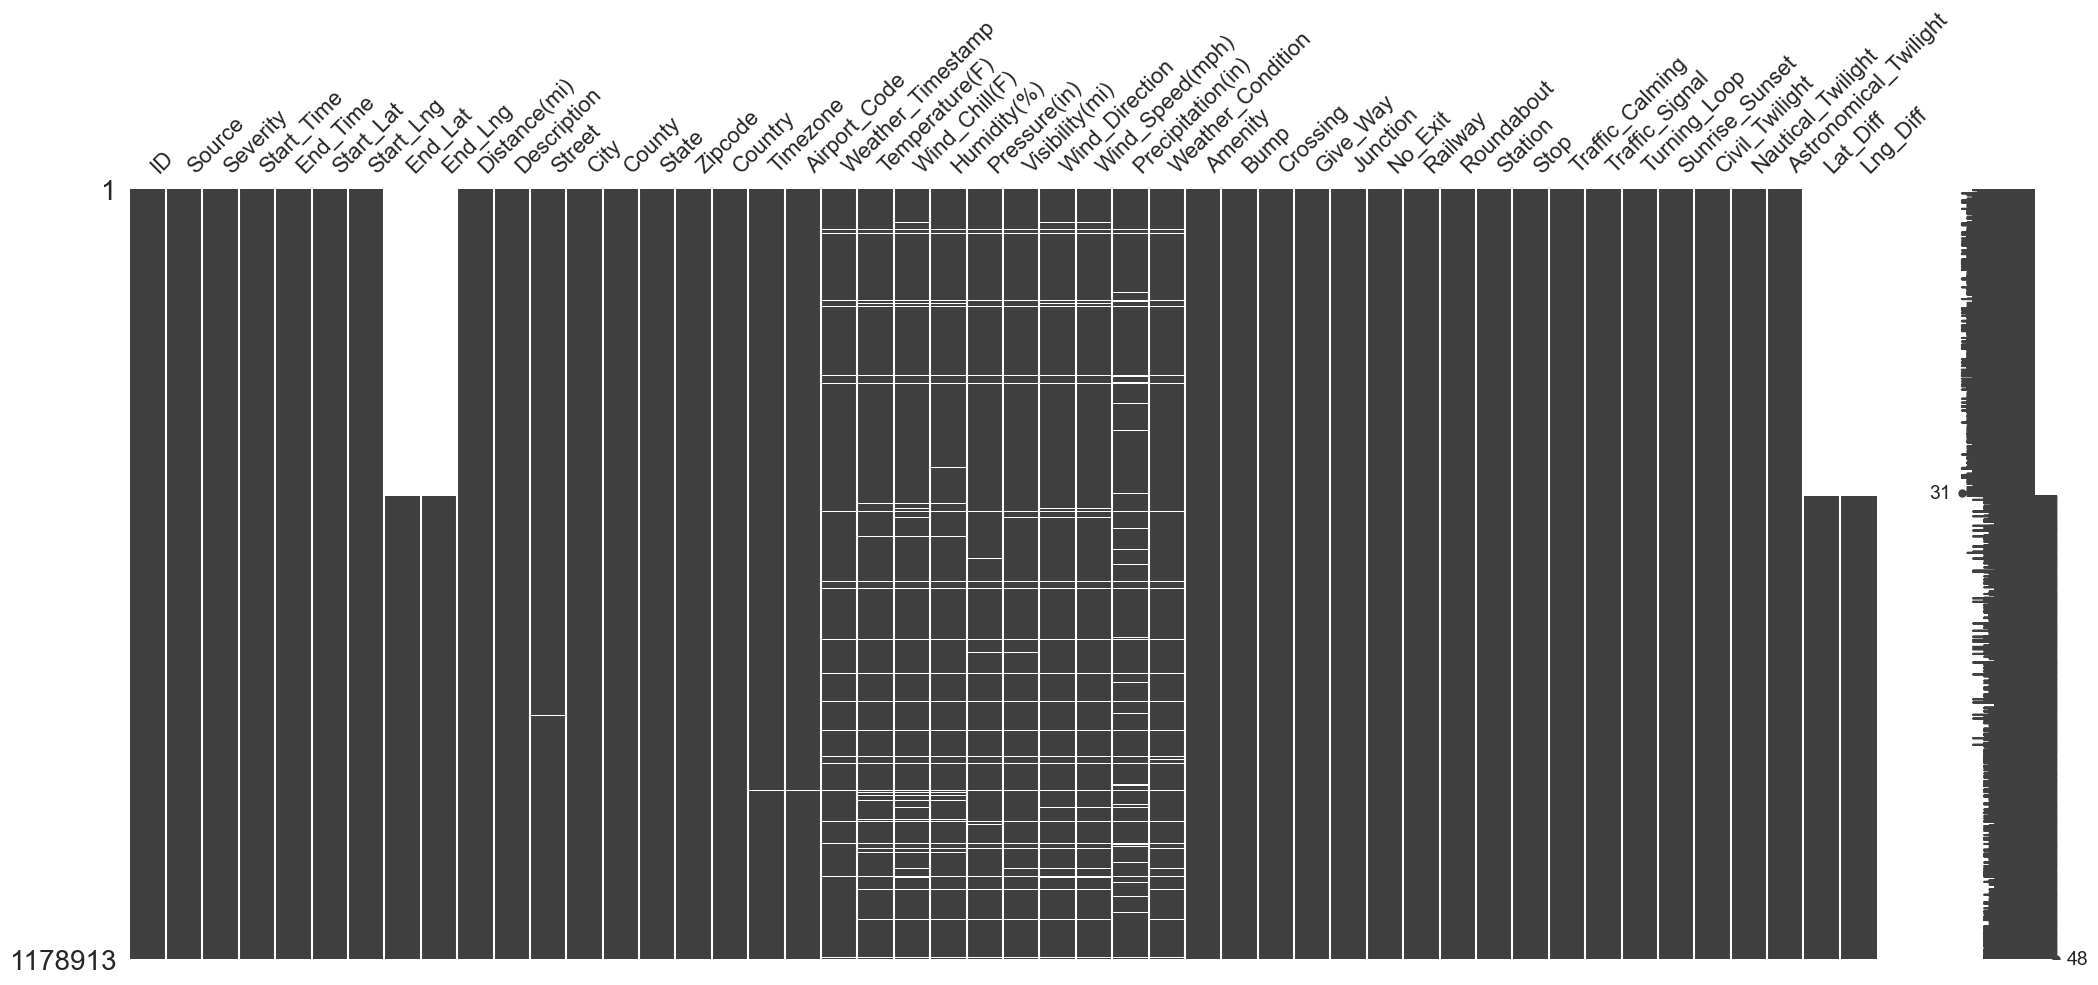

In [203]:
!pip install missingno

import missingno as msno
msno.matrix(df)

Keterangan terkait 4 kolom terakhir: 
- hilang di baris yang sama

**Penjelasan Kolom**
- Sunrise_Sunset : indikator siang dan malam (Day == matahari || Night == tidak ada matahari)
- Civil_Twilight : kondisi cahaya paling terang. momen krusial pengemudi bingung menyalakan lampu atau tidak
- Nautical_Twilight : kondisi cahaya sangat minim
- Astronomical_Twilight: langit sudah gelap total

Karena US memiliki 4 musim, kondisi langit di musim2 tertentu itu berbeda tiap jamnya. Makanya dibikin kolom seperti ini. Artinya, kolom ini **redundansi**

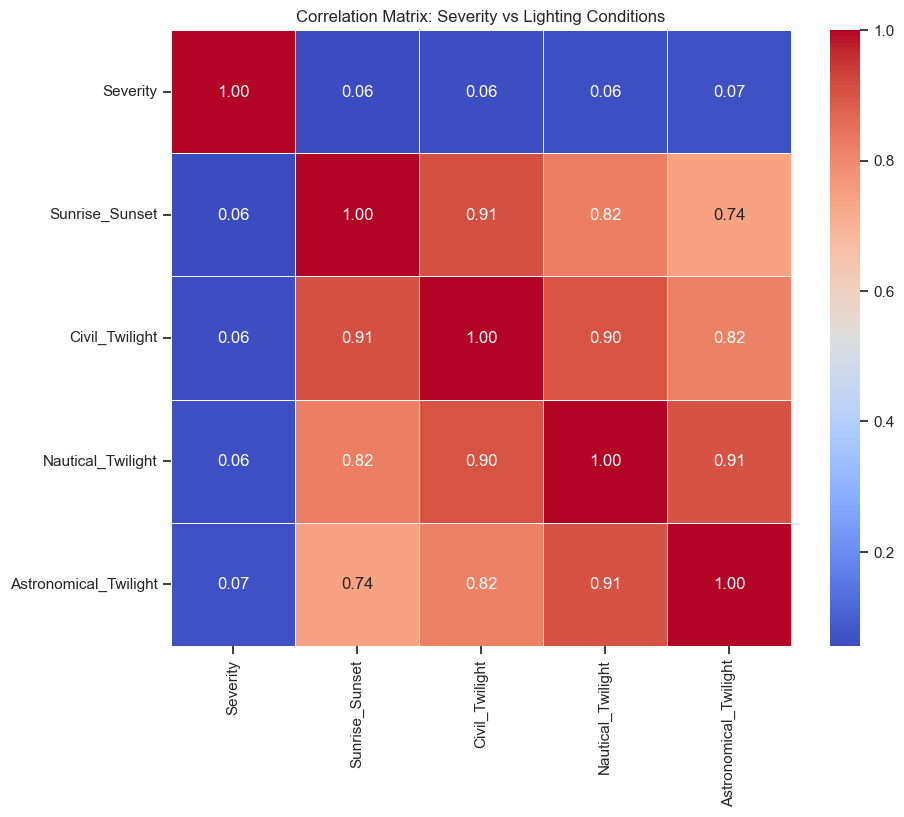

In [204]:
cols_to_analyze = ['Severity', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']
df_corr = df[cols_to_analyze].copy()

for col in cols_to_analyze[1:]:
    df_corr[col] = df_corr[col].map({'Day': 1, 'Night': 0})

correlation_matrix = df_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: Severity vs Lighting Conditions')
plt.show()

Korelasi terbesar dimiliki oleh kolom Astronomical_Twilight. 
**Drop kolom lainnya**

In [205]:
df[['Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']].head()

,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,Night,Night,Night,Day
1,Night,Night,Night,Night
2,Night,Night,Night,Night
3,Night,Night,Night,Night
4,Night,Night,Night,Night


Korelasi Pearson antara Temperature dan Wind Chill: 0.9931


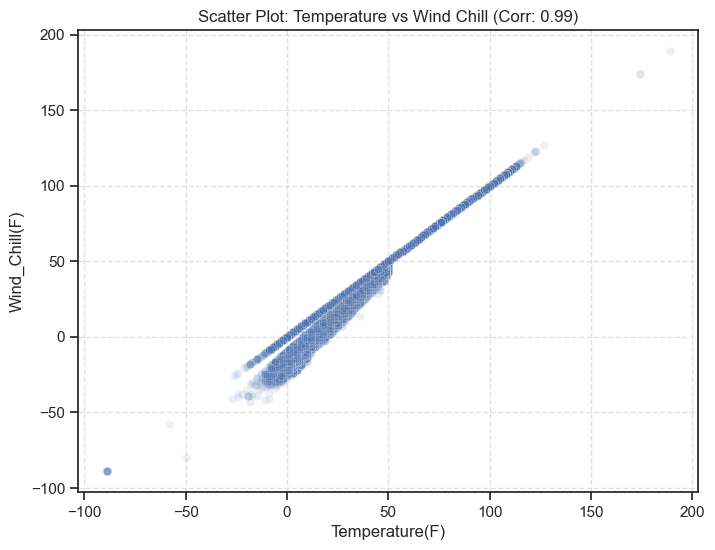

In [206]:
# Cek korelasi pearson antara Temperature dan Wind Chill

temp_wind_data = df[['Temperature(F)', 'Wind_Chill(F)']].dropna()

correlation = temp_wind_data['Temperature(F)'].corr(temp_wind_data['Wind_Chill(F)'])

print(f"Korelasi Pearson antara Temperature dan Wind Chill: {correlation:.4f}")

# 3. Visualisasi dengan Scatter Plot (untuk melihat pola hubungan)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Temperature(F)', y='Wind_Chill(F)', data=temp_wind_data, alpha=0.1) # alpha=0.1 karena ada 500rb baris
plt.title(f'Scatter Plot: Temperature vs Wind Chill (Corr: {correlation:.2f})')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Keputusan

Drop kolom End_Lat, Start_Lat, End_Lng, Start_Lng, Sunrise_Sunset, Civil_Twilight, Nautical_Twilight, Wind_Chill, ID, Description, Street, Zipcode, Airport_Code, Weather_Timestamp, Country, Turning_Loop, Source

In [207]:
# Hapus kolom tidak penting
cols_to_drop = [
    'End_Lat', 'End_Lng', 'Start_Lat', 'Start_Lng', 'Sunrise_Sunset', 'Civil_Twilight', 
    'Nautical_Twilight', 'Wind_Chill(F)', 'ID', 'Description', 
    'Street', 'Zipcode', 'Airport_Code', 'Weather_Timestamp', 
    'Country', 'Turning_Loop', 'Source', 'Lat_Diff', 'Lng_Diff'
]

df = df.drop(columns=cols_to_drop, errors='ignore')

## Persebaran atau Kondisi Data Sebelum di Impute

C:\Users\frans\AppData\Local\Temp\ipykernel_9080\1674380632.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\frans\AppData\Local\Temp\ipykernel_9080\1674380632.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\frans\AppData\Local\Temp\ipykernel_9080\1674380632.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\frans\AppData\Local\Temp\ipykernel_9080\1674380632.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same ef

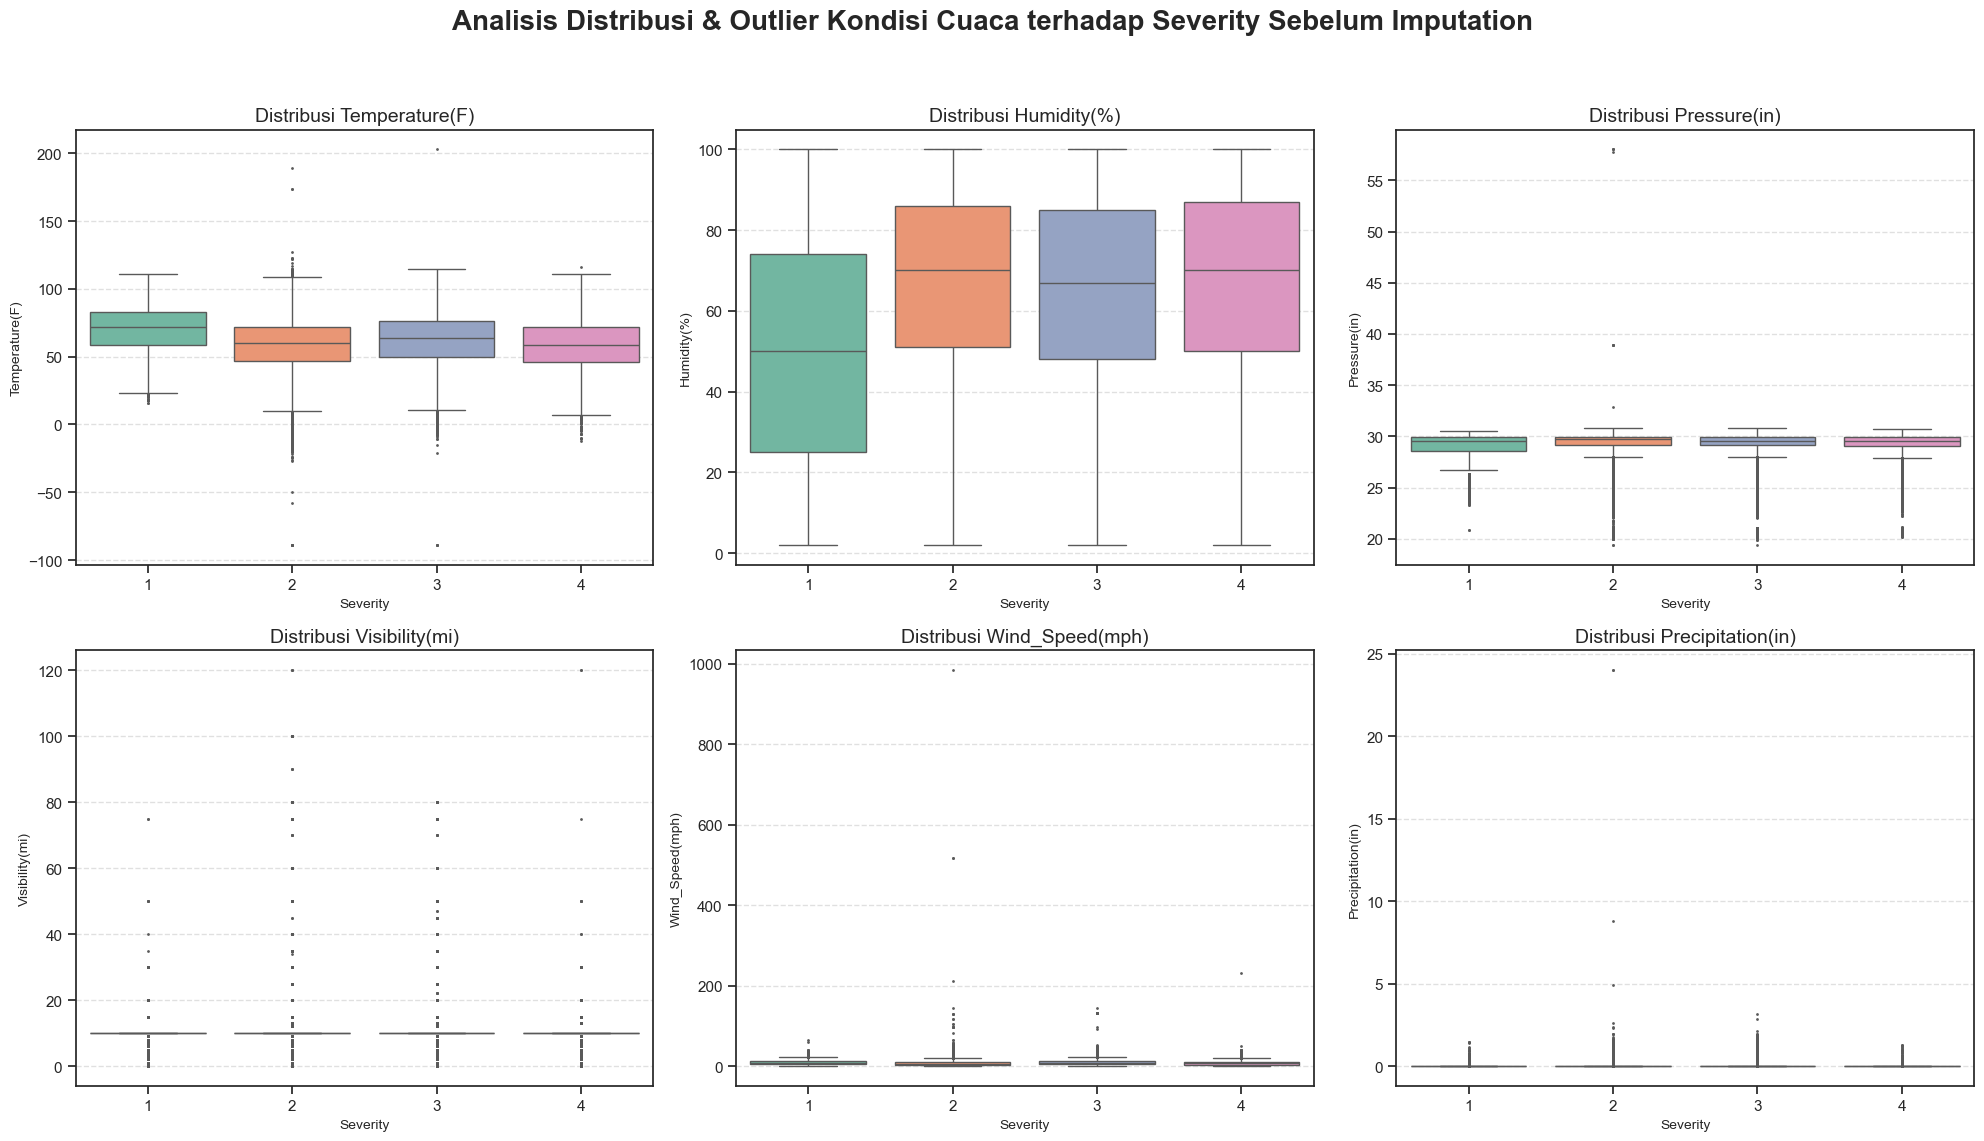

In [208]:
# Visualisasi distribusi data di kolom numerikal
weather_cols = [
    'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 
    'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)'
]

sns.set_theme(style="ticks")

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))
fig.suptitle('Analisis Distribusi & Outlier Kondisi Cuaca terhadap Severity Sebelum Imputation', fontsize=20, fontweight='bold')

for i, col in enumerate(weather_cols):
    row = i // 3
    col_idx = i % 3
    ax = axes[row, col_idx]
    
    sns.boxplot(data=df, x='Severity', y=col, ax=ax, palette='Set2', fliersize=1)

    ax.set_title(f'Distribusi {col}', fontsize=14)
    ax.set_xlabel('Severity', fontsize=10)
    ax.set_ylabel(col, fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Melalui visualisasi tersebut, dapat dilihat bahwa:**
- Semua kolom memiliki outlier yang tidak wajar, kecuali kolom Humidity. Kita bisa mempertimbangkan untuk impute dengam metode groupby Weather_Condition dengan median

**Setelah melihat missing value, tipe data, nilai unik, dan nama dari setiap kolom, ada beberapa to do yang harus dikerjakan:**
- Mengubah variabel time-time jadi datetype
- Banyak outlier ga masuk akal, Cari data trus yg di range sesuai datanya (Capping)
- Simplify kategori untuk kolom `Weather_Condition` dan `Wind Direction` karena dia berjumlah 108 nilai unik
- Impute `Weather_Condition` based on angka numerikal
- Impute kolom `Temperature(F)`, `Humidity(%)`, `Pressure(in)` `Visibility(mi)`, `Precipitation(in)` dan `Wind_Speed(mph)` (kolom numerikal) berdasarkan `Weather_Condition`
- Impute kolom City based on County
- Buat Geoplot dari kolom `State`
- Bikin kolom duration
- Impute End_Time based on severity dan duration (dari data yang ada)
- Impute Civil_Twilight based on Hour, Date, + State
- Impute Wind_Direction based on Jam + City
- Impute Duration 
- Membuat kolom road_features



In [209]:
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)
correlations = df.select_dtypes(include=[np.number]).corr()['Severity'].sort_values(ascending=False)
print("Korelasi Fitur terhadap Severity di Awal:")
print(correlations)

Korelasi Fitur terhadap Severity di Awal:
Severity             1.000000
Distance(mi)         0.100393
Wind_Speed(mph)      0.046215
Junction             0.031613
Precipitation(in)    0.028273
Humidity(%)          0.022308
Temperature(F)       0.010252
Traffic_Calming      0.001406
Bump                -0.000674
Roundabout          -0.001639
Give_Way            -0.005675
No_Exit             -0.007931
Railway             -0.012659
Pressure(in)        -0.013124
Visibility(mi)      -0.017271
Amenity             -0.020518
Station             -0.034228
Stop                -0.036607
Crossing            -0.111245
Traffic_Signal      -0.117975
Name: Severity, dtype: float64


## Preprocessing Tahap 1

In [210]:
# Mengubah tipe data ke datetype
cols_to_fix = ['Start_Time', 'End_Time']

for col in cols_to_fix:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print(df[cols_to_fix].dtypes)
df[cols_to_fix].head()

Start_Time    datetime64[ns]
End_Time      datetime64[ns]
dtype: object


,Start_Time,End_Time
0,2020-12-28 05:55:31,2021-01-18 05:00:00
1,2020-12-31 22:57:02,2021-01-01 00:29:02
2,2020-12-31 22:03:27,2021-01-01 01:43:05
3,2020-12-31 22:58:36,2021-01-01 01:02:45
4,2020-12-31 23:32:07,2021-01-01 00:51:14


In [211]:
# Proses Capping Berdasarkan Data yang Ada
constraints = {
    'Temperature(F)': {'min': 21.3, 'max': 98.7},
    'Humidity(%)': {'min': 32.3, 'max': 95.6},
    'Pressure(in)': {'min': 29.3706, 'max': 30.6876},
    'Visibility(mi)': {'min': 4.0, 'max': 9.9},
    'Wind_Speed(mph)': {'min': 5.7, 'max': 33.8},
    'Precipitation(in)': {'min': 0.0, 'max': 2.7}
}

for col, bounds in constraints.items():
    if col in df.columns:
        df[col] = df[col].clip(lower=bounds['min'], upper=bounds['max'])

In [212]:
weather_summary = df.groupby('Weather_Condition').agg({
    'Precipitation(in)': 'mean',
    'Visibility(mi)': 'mean',
    'Temperature(F)': 'mean',
    'Severity': 'count' 
}).rename(columns={'Severity': 'Count'}).sort_values(by='Count', ascending=False)

weather_summary = weather_summary.round(2)

print("Rata-rata Fitur Numerik per Kategori Cuaca:")
print(weather_summary)

Rata-rata Fitur Numerik per Kategori Cuaca:
                           Precipitation(in)  Visibility(mi)  Temperature(F)  \
Weather_Condition                                                              
Fair                                    0.00            9.70           61.04   
Cloudy                                  0.00            9.13           54.77   
Mostly Cloudy                           0.00            9.68           64.97   
Partly Cloudy                           0.00            9.69           66.40   
Light Rain                              0.03            7.13           56.68   
...                                      ...             ...             ...   
Mist / Windy                             NaN            5.00             NaN   
Sand / Dust Whirls Nearby               0.00            9.90           98.70   
Thunder and Hail                        0.16            4.00           60.00   
Sleet / Windy                           0.06            4.00           27.00

In [213]:
# Simplifikasi kolom Wind_Direction
df.loc[df['Wind_Direction']=='Calm','Wind_Direction'] = 'CALM'
df.loc[(df['Wind_Direction']=='West')|(df['Wind_Direction']=='WSW')|(df['Wind_Direction']=='WNW'),'Wind_Direction'] = 'W'
df.loc[(df['Wind_Direction']=='South')|(df['Wind_Direction']=='SSW')|(df['Wind_Direction']=='SSE'),'Wind_Direction'] = 'S'
df.loc[(df['Wind_Direction']=='North')|(df['Wind_Direction']=='NNW')|(df['Wind_Direction']=='NNE'),'Wind_Direction'] = 'N'
df.loc[(df['Wind_Direction']=='East')|(df['Wind_Direction']=='ESE')|(df['Wind_Direction']=='ENE'),'Wind_Direction'] = 'E'
df.loc[df['Wind_Direction']=='Variable','Wind_Direction'] = 'VAR'

print("Wind Direction after simplification: ", df['Wind_Direction'].unique())
print('Jumlah nilai unik Wind Direction:', df.Wind_Direction.nunique())

Wind Direction after simplification:  ['S' 'CALM' 'E' 'SE' 'W' 'NW' 'N' 'SW' 'VAR' nan 'NE']
Jumlah nilai unik Wind Direction: 10


In [214]:
# Cari tau kategori di Weather_Condition
df.Weather_Condition.unique()

array(['Fair', 'Mostly Cloudy', 'Cloudy', 'Light Rain',
       'Light Rain / Windy', 'Light Snow', 'Partly Cloudy', 'Rain',
       'Haze', nan, 'Wintry Mix', 'Fog', 'Light Drizzle', 'Heavy Rain',
       'T-Storm', 'Fair / Windy', 'Drizzle and Fog',
       'Partly Cloudy / Windy', 'Light Rain with Thunder', 'Rain / Windy',
       'Heavy T-Storm', 'Cloudy / Windy', 'Heavy Rain / Windy',
       'Light Freezing Rain', 'Mist', 'Snow', 'Light Freezing Drizzle',
       'Drizzle', 'N/A Precipitation', 'Mostly Cloudy / Windy',
       'Wintry Mix / Windy', 'Light Snow / Windy', 'Heavy Snow',
       'Patches of Fog', 'Showers in the Vicinity', 'Shallow Fog',
       'Thunder', 'Snow / Windy', 'Heavy Snow / Windy', 'T-Storm / Windy',
       'Fog / Windy', 'Haze / Windy', 'Heavy T-Storm / Windy',
       'Thunder in the Vicinity', 'Snow and Sleet / Windy',
       'Blowing Snow / Windy', 'Blowing Snow', 'Light Snow and Sleet',
       'Light Sleet', 'Smoke', 'Heavy Drizzle', 'Thunder / Windy',
       '

In [215]:
# Simplifikasi kolom Weather_Condition
conditions = [
    # 1. HAIL & SLEET: Paling spesifik dan ekstrem
    df['Weather_Condition'].str.contains('hail|sleet', case=False, na=False),
    
    # 2. THUNDERSTORM: Badai dan petir
    df['Weather_Condition'].str.contains('thunder|t-storm|squalls', case=False, na=False),
    
    # 3. SNOW: Salju dan kondisi beku (Wintry Mix masuk sini)
    df['Weather_Condition'].str.contains('snow|wintry|freezing|blizzard', case=False, na=False),
    
    # 4. RAIN: Semua jenis hujan dan gerimis
    df['Weather_Condition'].str.contains('rain|drizzle|shower|precipitation', case=False, na=False),
    
    # 5. FOG: Kabut, asap, dan debu
    df['Weather_Condition'].str.contains('fog|haze|mist|smoke|dust|sand|patches', case=False, na=False),
    
    # 6. CLEAR/CLOUDY: Cerah atau mendung tanpa presipitasi
    df['Weather_Condition'].str.contains('fair|cloudy|clear|overcast', case=False, na=False)
]

choices = ['hail', 'thunderstorm', 'snow', 'rain', 'fog', 'clear']

# Eksekusi pembersihan
df['Weather_Condition'] = np.select(conditions, choices, default='other')

# Cek hasil
print("Distribusi Hasil Simplifikasi:")
print(df['Weather_Condition'].value_counts())

Distribusi Hasil Simplifikasi:
Weather_Clean
clear           985581
rain             92847
fog              40111
other            29974
snow             19747
thunderstorm     10558
hail                95
Name: count, dtype: int64


In [216]:
df.Weather_Condition.unique()

array(['Fair', 'Mostly Cloudy', 'Cloudy', 'Light Rain',
       'Light Rain / Windy', 'Light Snow', 'Partly Cloudy', 'Rain',
       'Haze', nan, 'Wintry Mix', 'Fog', 'Light Drizzle', 'Heavy Rain',
       'T-Storm', 'Fair / Windy', 'Drizzle and Fog',
       'Partly Cloudy / Windy', 'Light Rain with Thunder', 'Rain / Windy',
       'Heavy T-Storm', 'Cloudy / Windy', 'Heavy Rain / Windy',
       'Light Freezing Rain', 'Mist', 'Snow', 'Light Freezing Drizzle',
       'Drizzle', 'N/A Precipitation', 'Mostly Cloudy / Windy',
       'Wintry Mix / Windy', 'Light Snow / Windy', 'Heavy Snow',
       'Patches of Fog', 'Showers in the Vicinity', 'Shallow Fog',
       'Thunder', 'Snow / Windy', 'Heavy Snow / Windy', 'T-Storm / Windy',
       'Fog / Windy', 'Haze / Windy', 'Heavy T-Storm / Windy',
       'Thunder in the Vicinity', 'Snow and Sleet / Windy',
       'Blowing Snow / Windy', 'Blowing Snow', 'Light Snow and Sleet',
       'Light Sleet', 'Smoke', 'Heavy Drizzle', 'Thunder / Windy',
       '

In [217]:
weather_summary = df.groupby('Weather_Condition').agg({
    'Precipitation(in)': 'mean',
    'Visibility(mi)': 'mean',
    'Temperature(F)': 'mean',
    'Severity': 'count' 
}).rename(columns={'Severity': 'Count'}).sort_values(by='Count', ascending=False)

weather_summary = weather_summary.round(2)

print("Rata-rata Fitur Numerik per Kategori Cuaca:")
print(weather_summary)

Rata-rata Fitur Numerik per Kategori Cuaca:
                           Precipitation(in)  Visibility(mi)  Temperature(F)  \
Weather_Condition                                                              
Fair                                    0.00            9.70           61.04   
Cloudy                                  0.00            9.13           54.77   
Mostly Cloudy                           0.00            9.68           64.97   
Partly Cloudy                           0.00            9.69           66.40   
Light Rain                              0.03            7.13           56.68   
...                                      ...             ...             ...   
Mist / Windy                             NaN            5.00             NaN   
Sand / Dust Whirls Nearby               0.00            9.90           98.70   
Thunder and Hail                        0.16            4.00           60.00   
Sleet / Windy                           0.06            4.00           27.00

In [218]:
weather_summary = df.groupby('Weather_Condition').agg({
    'Precipitation(in)': ['mean', 'max'],
    'Temperature(F)': ['mean', 'max'],
    'Visibility(mi)': 'mean',
    'Severity': 'count'
})

weather_summary.columns = [
    'Precip_Avg', 'Precip_Max', 
    'Temp_Avg', 'Temp_Max', 
    'Visibility_Avg', 'Accident_Count'
]

weather_summary = weather_summary.sort_values(by='Accident_Count', ascending=False).round(2)

print("Statistik Kondisi Cuaca terhadap Kecelakaan:")
print(weather_summary)

Statistik Kondisi Cuaca terhadap Kecelakaan:
                           Precip_Avg  Precip_Max  Temp_Avg  Temp_Max  \
Weather_Condition                                                       
Fair                             0.00        1.00     61.04      98.7   
Cloudy                           0.00        2.70     54.77      98.7   
Mostly Cloudy                    0.00        1.50     64.97      98.7   
Partly Cloudy                    0.00        2.70     66.40      98.7   
Light Rain                       0.03        1.34     56.68      98.7   
...                               ...         ...       ...       ...   
Mist / Windy                      NaN         NaN       NaN       NaN   
Sand / Dust Whirls Nearby        0.00        0.00     98.70      98.7   
Thunder and Hail                 0.16        0.16     60.00      60.0   
Sleet / Windy                    0.06        0.06     27.00      27.0   
Drifting Snow                    0.00        0.00     21.30      21.3   

     

In [219]:
# Impute Weather_Condition based on median Temperature and Precipitation

df['Temperature(F)'] = pd.to_numeric(df['Temperature(F)'], errors='coerce')
df['Precipitation(in)'] = pd.to_numeric(df['Precipitation(in)'], errors='coerce')
df['Visibility(mi)'] = pd.to_numeric(df['Visibility(mi)'], errors='coerce')

mask_missing = df['Weather_Condition'].isna()

conditions = [
    # 1. THUNDERSTORM: Presipitasi sangat tinggi
    mask_missing & (precip > 0.11),
    
    # 2. SNOW: Presipitasi ada + Suhu di bawah/sama dengan titik beku (32 F)
    mask_missing & (precip > 0) & (temp <= 32),
    
    # 3. RAIN: Presipitasi ada + Suhu di atas titik beku
    mask_missing & (precip > 0) & (temp > 32),
    
    # 4. FOG: Tidak ada hujan + Jarak pandang sangat buruk (Kabut tebal)
    mask_missing & (precip == 0) & (vis <= 0.25),
    
    # 5. CLEAR: Tidak ada hujan + Jarak pandang sangat baik
    mask_missing & (precip == 0) & (vis >= 7),
    
    # 6. CLOUDY: Tidak ada hujan + Jarak pandang terbatas/sedang
    mask_missing & (precip == 0) & (vis.between(0.26, 6.9))
]

choices = ['thunderstorm', 'snow', 'rain', 'fog', 'Clear', 'clear']

df['Weather_Condition'] = np.select(conditions, choices, default=df['Weather_Condition'])


NameError: name 'precip' is not defined

In [ ]:
missing = df.Weather_Condition.isnull().sum()
print(missing)

0


In [ ]:
# Impute kolom City based on modus di County
df['City'] = df.groupby('County')['City'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown City")
)
df['City'] = df['City'].fillna("Unknown City")

In [ ]:
# Impute kolom numerikal based on Weather_Condition
def super_impute(df, numeric_cols):
    df['Weather_Condition'] = df['Weather_Condition'].fillna('Unknown')
    
    for col in numeric_cols:
        # Median per Weather_Condition
        df[col] = df[col].fillna(df.groupby('Weather_Condition')[col].transform('median'))
        
        # Jika masih ada yang kosong impute pakai median global
        global_median = df[col].median()
        df[col] = df[col].fillna(global_median)
        
        # 4. Cek sisa Missing Value untuk kolom ini
        remaining = df[col].isnull().sum()
        print(f"Selesai: {col} | Sisa NaN: {remaining}")
    
    return df

# Daftar kolom sesuai datasetmu
cols_to_fix = [
    'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 
    'Visibility(mi)', 'Precipitation(in)', 'Wind_Speed(mph)'
]

# Eksekusi!
df = super_impute(df, cols_to_fix)

Selesai: Temperature(F) | Sisa NaN: 0
Selesai: Humidity(%) | Sisa NaN: 0
Selesai: Pressure(in) | Sisa NaN: 0
Selesai: Visibility(mi) | Sisa NaN: 0
Selesai: Precipitation(in) | Sisa NaN: 0
Selesai: Wind_Speed(mph) | Sisa NaN: 0


In [ ]:
# Bikin kolom duration untuk mengetahui seberapa lama traffic menyebabkan kemacetan
df['Duration'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60

In [ ]:
# Impute End_Time
df['Duration'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60
mean_duration = df.groupby('Severity')['Duration'].transform('mean')

mask = df['End_Time'].isna()
df.loc[mask, 'End_Time'] = df.loc[mask, 'Start_Time'] + pd.to_timedelta(mean_duration[mask], unit='m')

In [ ]:
# Impute kolom Astronomical_Twilight
df['Month'] = df['Start_Time'].dt.month
df['Hour'] = df['Start_Time'].dt.hour

def get_mode(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else np.nan

fallback_levels = [
    ['State', 'Month', 'Hour'],
    ['Timezone', 'Month', 'Hour'],
    ['Hour']
]

for level in fallback_levels:
    df['Astronomical_Twilight'] = df['Astronomical_Twilight'].fillna(
        df.groupby(level)['Astronomical_Twilight'].transform(get_mode)
    )


In [ ]:
df['Duration'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60

In [ ]:
# Impute kolom Wind_Direction based on City dan Start_Time
df = df.sort_values(by=['City', 'Start_Time'])

df['Wind_Direction'] = df.groupby('City')['Wind_Direction'].ffill()
df['Wind_Direction'] = df['Wind_Direction'].fillna('CALM')

In [ ]:
# Membuat kolom road_features
road_features = [
    "Amenity",
    "Bump",
    "Crossing",
    "Give_Way",
    "Junction",
    "No_Exit",
    "Railway",
    "Roundabout",
    "Station",
    "Stop",
    "Traffic_Calming",
    "Traffic_Signal"
]

df["Road_Features"] = df[road_features].sum(axis=1)

In [ ]:
# Menghitung nilai unik setelah simplifikasi
unique_counts = df.nunique().sort_values(ascending=False)

unique_df = unique_counts.reset_index()
unique_df.columns = ['Nama Kolom', 'Jumlah Nilai Unik']
print("Jumlah Nilai Unik per Kolom (Urutan Terbanyak):")
print(unique_df)


Jumlah Nilai Unik per Kolom (Urutan Terbanyak):
               Nama Kolom  Jumlah Nilai Unik
0                End_Time             979750
1              Start_Time             875621
2                Duration              45956
3            Distance(mi)              10408
4                    City               9541
5                  County               1565
6       Precipitation(in)                175
7            Pressure(in)                134
8       Weather_Condition                 85
9          Temperature(F)                 79
10            Humidity(%)                 65
11                  State                 49
12        Wind_Speed(mph)                 27
13                   Hour                 24
14                  Month                 12
15         Wind_Direction                 10
16         Visibility(mi)                  7
17          Road_Features                  7
18     Weather_Simplified                  6
19               Severity                  4
20     

## Visualisasi Data Numerical Setelah di Impute

C:\Users\frans\AppData\Local\Temp\ipykernel_9080\3256269883.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\frans\AppData\Local\Temp\ipykernel_9080\3256269883.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\frans\AppData\Local\Temp\ipykernel_9080\3256269883.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\frans\AppData\Local\Temp\ipykernel_9080\3256269883.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same ef

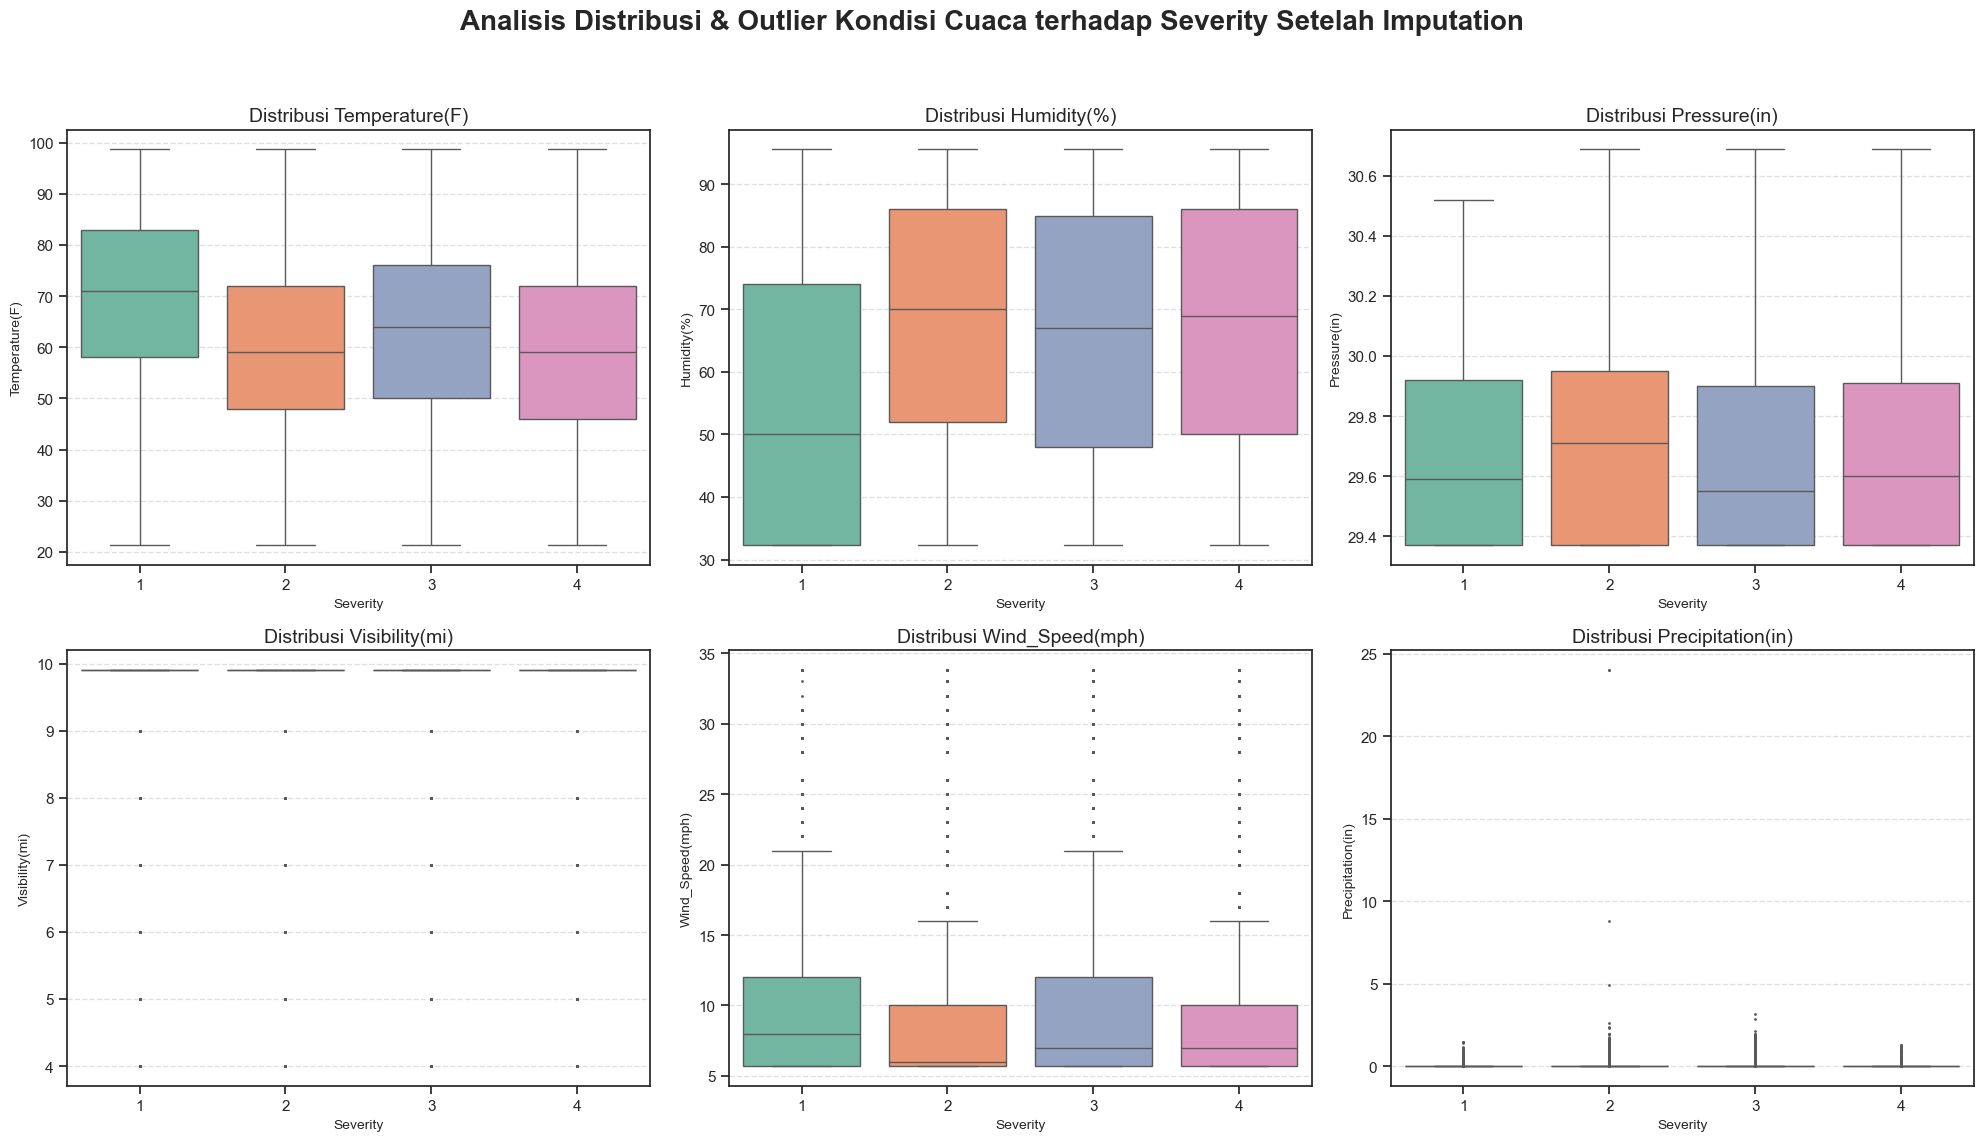

In [ ]:
# Visualisasi distribusi data di kolom numerikal
weather_cols = [
    'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 
    'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)'
]

sns.set_theme(style="ticks")

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))
fig.suptitle('Analisis Distribusi & Outlier Kondisi Cuaca terhadap Severity Setelah Imputation', fontsize=20, fontweight='bold')

for i, col in enumerate(weather_cols):
    row = i // 3
    col_idx = i % 3
    ax = axes[row, col_idx]
    
    sns.boxplot(data=df, x='Severity', y=col, ax=ax, palette='Set2', fliersize=1)

    ax.set_title(f'Distribusi {col}', fontsize=14)
    ax.set_xlabel('Severity', fontsize=10)
    ax.set_ylabel(col, fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
df = df.drop(columns='Timezone', errors='ignore')

In [ ]:
df.isnull().sum()

Severity                 0
Start_Time               0
End_Time                 0
Distance(mi)             0
City                     0
County                   0
State                    0
Temperature(F)           0
Humidity(%)              0
Pressure(in)             0
Visibility(mi)           0
Wind_Direction           0
Wind_Speed(mph)          0
Precipitation(in)        0
Weather_Condition        0
Amenity                  0
Bump                     0
Crossing                 0
Give_Way                 0
Junction                 0
No_Exit                  0
Railway                  0
Roundabout               0
Station                  0
Stop                     0
Traffic_Calming          0
Traffic_Signal           0
Astronomical_Twilight    0
Weather_Simplified       0
Duration                 0
Month                    0
Hour                     0
Road_Features            0
dtype: int64

In [ ]:
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)
correlations = df.select_dtypes(include=[np.number]).corr()['Severity'].sort_values(ascending=False)
print("Korelasi Fitur terhadap Severity di Akhir:")
print(correlations)

Korelasi Fitur terhadap Severity di Akhir:
Severity             1.000000
Distance(mi)         0.100393
Wind_Speed(mph)      0.038292
Junction             0.031613
Hour                 0.029040
Precipitation(in)    0.028409
Humidity(%)          0.012427
Temperature(F)       0.009762
Traffic_Calming      0.001406
Duration            -0.000358
Bump                -0.000674
Roundabout          -0.001639
Give_Way            -0.005675
No_Exit             -0.007931
Railway             -0.012659
Amenity             -0.020518
Visibility(mi)      -0.023303
Station             -0.034228
Stop                -0.036607
Pressure(in)        -0.044458
Month               -0.095685
Crossing            -0.111245
Road_Features       -0.116210
Traffic_Signal      -0.117975
Name: Severity, dtype: float64


In [ ]:
df.shape

(1178913, 33)

In [ ]:
df.columns

Index(['Severity', 'Start_Time', 'End_Time', 'Distance(mi)', 'City', 'County',
       'State', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
       'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Astronomical_Twilight',
       'Weather_Simplified', 'Duration', 'Month', 'Hour', 'Road_Features'],
      dtype='object')

# EDA 2
Dilakukan setelah semua data rapi dan bagus

visualisasiin persebaran kecelakaan tiap bulannya

In [ ]:
# Bikin geoplot untuk kecelakaan terparah
state_counts = df['State'].value_counts().reset_index()
state_counts.columns = ['State', 'Total_Accidents']

fig = px.choropleth(state_counts, 
                    locations='State', 
                    locationmode="USA-states", 
                    color='Total_Accidents',
                    scope="usa",
                    color_continuous_scale="Reds",
                    title='Total Kecelakaan Lalu Lintas per Negara Bagian (USA)')

fig.show()

In [ ]:
df.State.value_counts()

State
CA    285532
FL    130362
TX     73488
SC     62789
NY     48805
NC     48633
VA     44803
PA     43189
MN     39193
OR     34452
AZ     29535
TN     28463
LA     26342
IL     25007
MD     24351
GA     23427
AL     20185
NJ     18590
OH     17240
UT     16192
MI     15763
CO     13889
OK     13590
WA     13211
MA     11101
MO     10372
CT      9341
IN      7806
KY      5568
WI      3933
IA      3649
AR      3090
KS      2644
DC      2632
NE      2493
DE      2478
MT      2450
NV      2442
RI      2387
ID      2319
MS      2019
NH      1496
NM      1436
WV      1171
ND       399
ME       281
VT       186
SD       160
WY        29
Name: count, dtype: int64

In [ ]:
# Cari tau state dengan rata2 severity tertinggi 
state_severity = df.groupby('State')['Severity'].mean().reset_index()

state_counts = df['State'].value_counts().reset_index()
state_counts.columns = ['State', 'Accident_Count']

map_data = pd.merge(state_severity, state_counts, on='State')

print(map_data.sort_values(by='Severity', ascending=False).head())

   State  Severity  Accident_Count
48    WY  3.275862              29
12    IL  2.611909           25007
46    WI  2.575896            3933
13    IN  2.545478            7806
22    MO  2.528153           10372


In [ ]:
fig = px.choropleth(
    map_data, 
    locations='State',            
    locationmode="USA-states",    
    color='Severity',             
    hover_name='State',           
    hover_data=['Accident_Count'],
    color_continuous_scale="Reds",
    scope="usa",                  
    title='Rata-rata Severity Kecelakaan per Negara Bagian'
)

fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

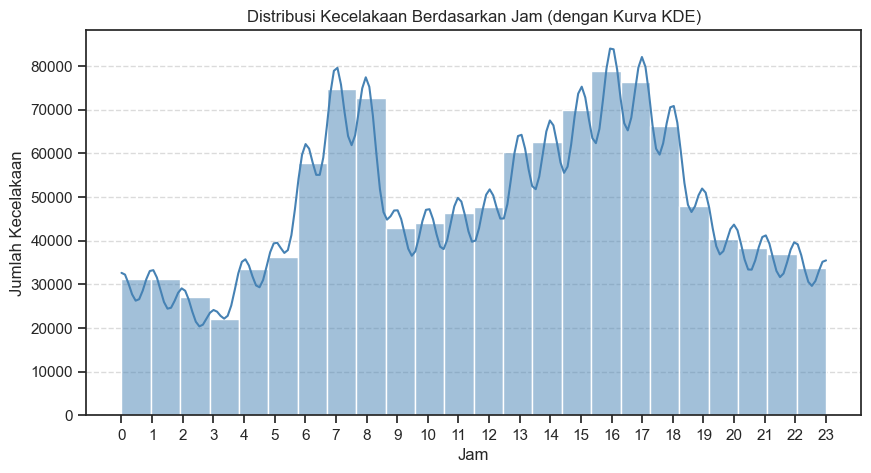

In [ ]:
# Distribusi Kecelakaan berdasarkan Waktu
df['Hour'] = df['Start_Time'].dt.hour
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="Hour", bins=24, kde=True, color="steelblue", stat="count")

plt.title("Distribusi Kecelakaan Berdasarkan Jam (dengan Kurva KDE)")
plt.xlabel("Jam")
plt.ylabel("Jumlah Kecelakaan")
plt.xticks(range(0, 24)) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

C:\Users\frans\AppData\Local\Temp\ipykernel_9080\2063745407.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




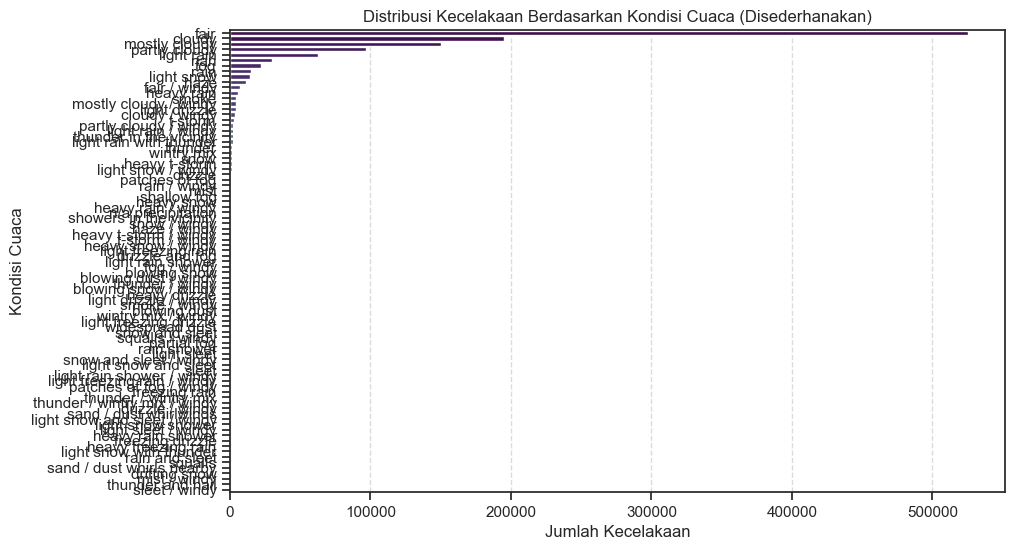

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Weather_Condition', order=df['Weather_Condition'].value_counts().index, palette='viridis')
plt.title('Distribusi Kecelakaan Berdasarkan Kondisi Cuaca (Disederhanakan)')
plt.xlabel('Jumlah Kecelakaan')
plt.ylabel('Kondisi Cuaca')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

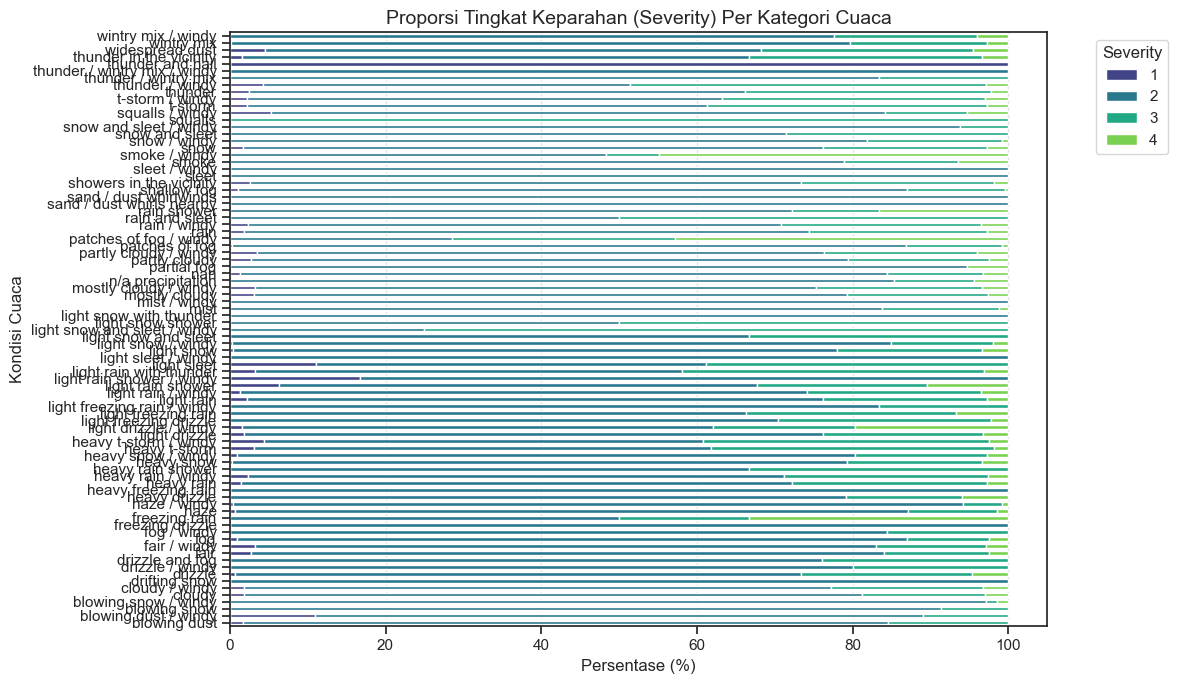

In [ ]:
weather_severity_cross = pd.crosstab(df['Weather_Condition'], df['Severity'])

weather_severity_pct = weather_severity_cross.div(weather_severity_cross.sum(1), axis=0) * 100

weather_severity_pct.plot(kind='barh', stacked=True, figsize=(12, 7), 
                          color=sns.color_palette("viridis", 4))

plt.title('Proporsi Tingkat Keparahan (Severity) Per Kategori Cuaca', fontsize=14)
plt.xlabel('Persentase (%)')
plt.ylabel('Kondisi Cuaca')
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

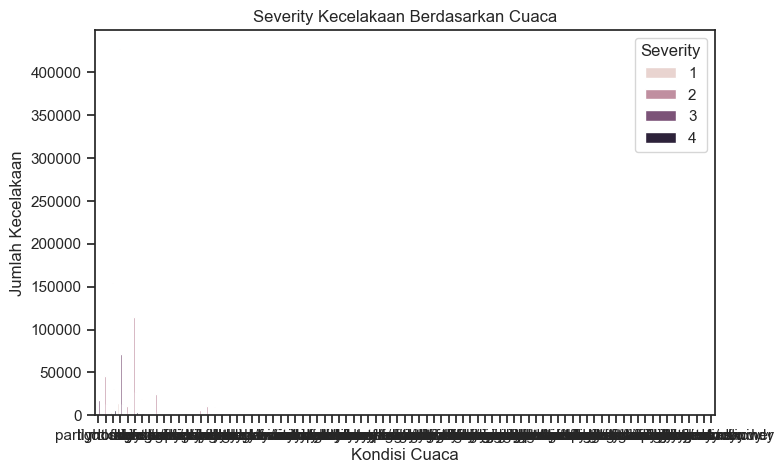

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Weather_Condition", hue="Severity")

plt.title("Severity Kecelakaan Berdasarkan Cuaca")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Jumlah Kecelakaan")

plt.show()

C:\Users\frans\AppData\Local\Temp\ipykernel_9080\4283050729.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




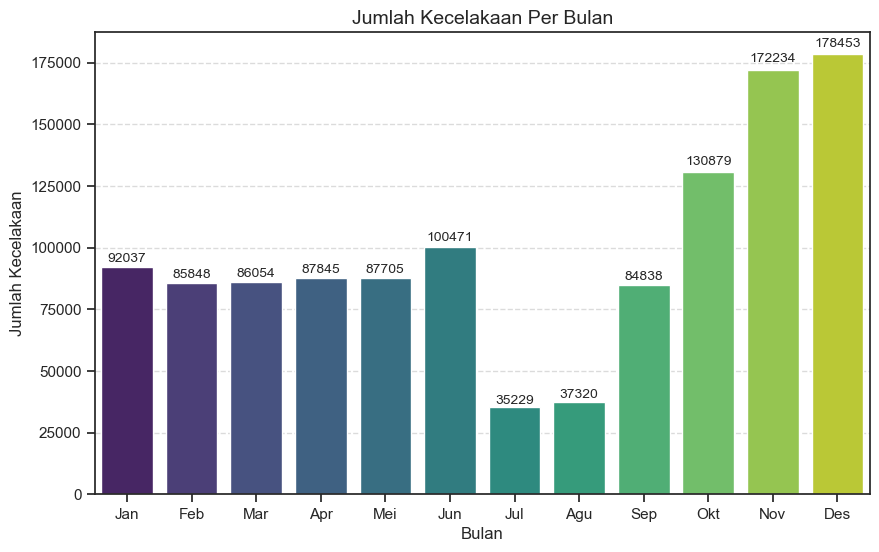

In [ ]:
# Distribusi per Bulan
monthly_counts = df['Month'].value_counts().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 
               'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']
plt.figure(figsize=(10, 6))
sns.barplot(x=month_names, y=monthly_counts.values, palette='viridis')

plt.title('Jumlah Kecelakaan Per Bulan', fontsize=14)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Jumlah Kecelakaan', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, val in enumerate(monthly_counts.values):
    plt.text(i, val + (val*0.01), f'{int(val)}', ha='center', va='bottom', fontsize=10)

plt.show()

C:\Users\frans\AppData\Local\Temp\ipykernel_9080\547927646.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




Text(0, 0.5, 'Rata-rata Severity (1-4)')

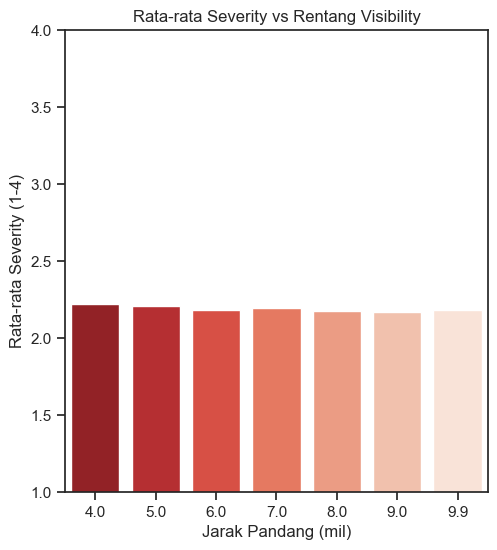

In [ ]:
# Pengaruh Visibility dengan Severity
vis_severity_mean = df.groupby('Visibility(mi)')['Severity'].mean().reset_index()

# 3. Plotting
plt.figure(figsize=(12, 6))

# Subplot 1: Bar Chart Rata-rata Severity
plt.subplot(1, 2, 1)
sns.barplot(data=vis_severity_mean, x='Visibility(mi)', y='Severity', palette='Reds_r')
plt.ylim(df['Severity'].min(), df['Severity'].max()) # Agar skala y adil
plt.title('Rata-rata Severity vs Rentang Visibility')
plt.xlabel('Jarak Pandang (mil)')
plt.ylabel('Rata-rata Severity (1-4)')

Visibility tidak memengaruhi Severity

C:\Users\frans\AppData\Local\Temp\ipykernel_9080\540499443.py:5: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\frans\AppData\Local\Temp\ipykernel_9080\540499443.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




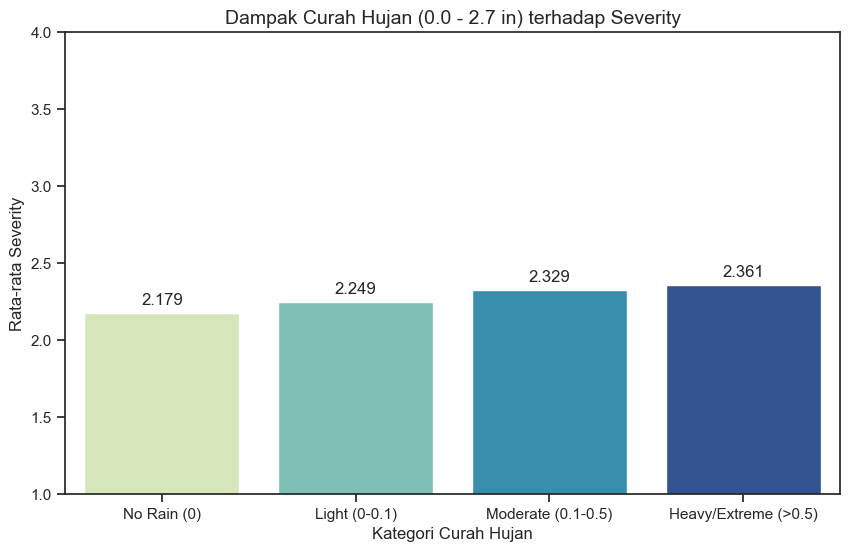

In [ ]:
# Hubungan curah hujan dengan severity
bins = [-0.01, 0.001, 0.1, 0.5, 2.7] 
labels = ['No Rain (0)', 'Light (0-0.1)', 'Moderate (0.1-0.5)', 'Heavy/Extreme (>0.5)']
df['Rain_Class'] = pd.cut(df['Precipitation(in)'], bins=bins, labels=labels)
rain_impact = df.groupby('Rain_Class')['Severity'].mean().reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=rain_impact, x='Rain_Class', y='Severity', palette='YlGnBu')

plt.title('Dampak Curah Hujan (0.0 - 2.7 in) terhadap Severity', fontsize=14)
plt.xlabel('Kategori Curah Hujan', fontsize=12)
plt.ylabel('Rata-rata Severity', fontsize=12)
plt.ylim(1, 4) 

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.show()

C:\Users\frans\AppData\Local\Temp\ipykernel_9080\2639928508.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




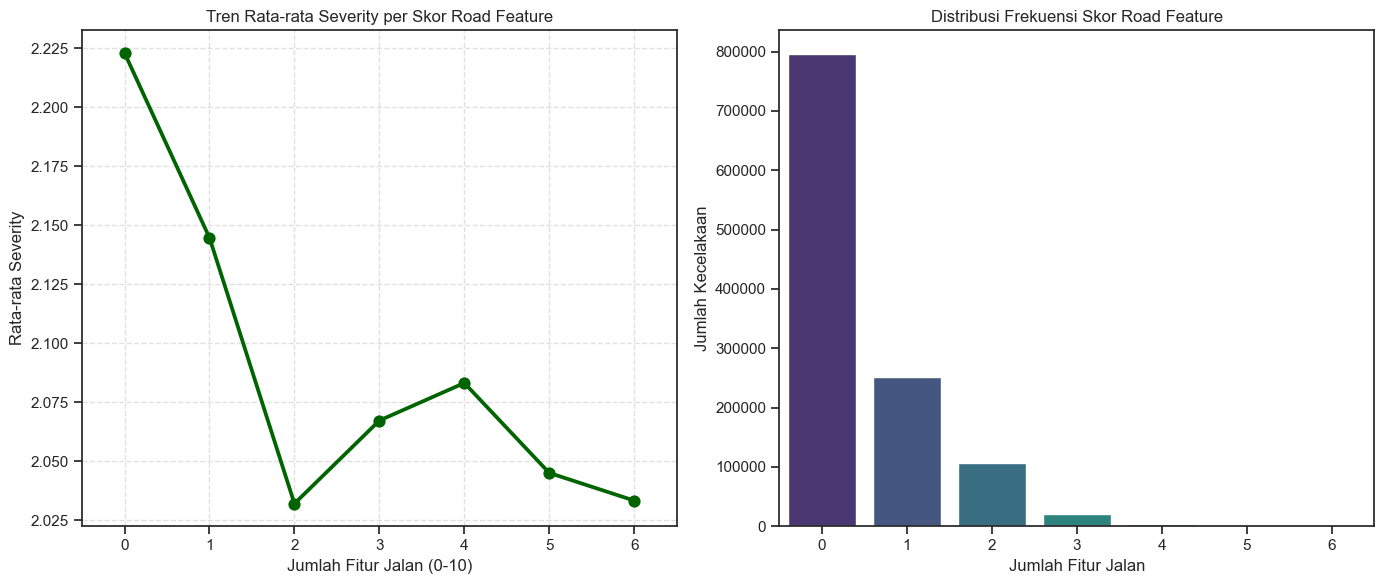

In [ ]:
# Hubungan road_features dengan severity
road_impact = df.groupby('Road_Features')['Severity'].mean().reset_index()

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.pointplot(data=road_impact, x='Road_Features', y='Severity', color='darkgreen')
plt.title('Tren Rata-rata Severity per Skor Road Feature')
plt.xlabel('Jumlah Fitur Jalan (0-10)')
plt.ylabel('Rata-rata Severity')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Road_Features', palette='viridis')
plt.title('Distribusi Frekuensi Skor Road Feature')
plt.xlabel('Jumlah Fitur Jalan')
plt.ylabel('Jumlah Kecelakaan')

plt.tight_layout()
plt.show()

In [ ]:
df.shape

(1178913, 34)

In [ ]:
df.columns

Index(['Severity', 'Start_Time', 'End_Time', 'Distance(mi)', 'City', 'County',
       'State', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
       'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Astronomical_Twilight',
       'Weather_Simplified', 'Duration', 'Month', 'Hour', 'Road_Features',
       'Rain_Class'],
      dtype='object')